# 02 · Correlation heatmaps: reported results and verification

## Context and contents

The thesis asks how carbon pools relate to soil and water conditions. Correlation
heatmaps summarise pairwise linear associations and show redundancy among environmental
variables. They do not estimate independent environmental effects.

This notebook (1) reads all four tables in `Heatmap.xlsx`; (2) draws their matrices
at A4 text width; (3) extracts carbon-response columns; and (4) compares reported
coefficients against available raw measurements. **The plots reproduce the reported
coefficients; they are not silently replaced by recomputed values.**

Run from top to bottom with **Python (ler)**. Keep the three Excel files and
`ecological_data.py` in the parent project folder, above `ipynb_files_2/`.
The kernel may start in either folder. Every plot is saved under
`ipynb_files_2/figures/`
as a vector PDF and a 300-dpi PNG, **160 mm wide**. Labels are 9.5–12 pt at that
printed width. Use the figures at full text width, not as half-width thumbnails.
The source spreadsheets are unchanged; numerical tables are under `ipynb_files_2/tables/`.

## Conventions

Pearson correlation is

$$
r_{xy}=\frac{\sum_i(x_i-\bar x)(y_i-\bar y)}
{\sqrt{\sum_i(x_i-\bar x)^2\sum_i(y_i-\bar y)^2}}.
$$

The colour scale is fixed at **−1 to +1**, centred at zero, with a blue–orange diverging
palette and numerical annotations. The upper triangle is omitted because it duplicates
the lower triangle. No clustering reorders the workbook variables.

Exported `*`/`**` suffixes are removed when parsing numbers. The supplied p-values
and $N=80$ are preserved in CSV tables; stars are not plotted because repeated-site
dependence and multiple comparisons are not addressed by these supplied tests.
The TBC heatmaps remain **reported results**: the supplied raw TBC block duplicates TDS,
so the TBC coefficients cannot be validated against authentic site-level biomass data.

In [1]:
FIGURE_GROUP = "02_heatmaps"

from pathlib import Path
import json
import json
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from IPython.display import display
# Locate the project root when the kernel starts here or in the parent folder.
PROJECT_ROOT = next(
    (folder for folder in (Path.cwd(), *Path.cwd().parents)
     if (folder / "ecological_data.py").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Run this notebook from the lyn project or ipynb_files_2 folder.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from ecological_data import (
    ROOT, KEYS, SEASONS, WETLANDS, load_scatter, load_pca,
    decode_pca, load_line_summary, load_heatmaps,
)

NOTEBOOK_DIR = ROOT / "ipynb_files_2"
FIG_DIR = NOTEBOOK_DIR / "figures" / FIGURE_GROUP
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR = NOTEBOOK_DIR / "tables"
TABLE_DIR.mkdir(exist_ok=True)
# A4 with 25-mm left/right margins: 160 mm available for a figure.
WIDTH = 160 / 25.4  # inches; figures should be placed at this width in the thesis
FIGURES = []
# A4 with 25-mm left/right margins: 160 mm available for a figure.
WIDTH = 160 / 25.4  # inches; figures should be placed at this width in the thesis
FIGURES = []
sns.set_theme(style="ticks", context="notebook", font="DejaVu Sans", rc={
    "font.size": 11, "axes.labelsize": 11, "axes.titlesize": 12,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "legend.fontsize": 10, "legend.title_fontsize": 10,
    "figure.dpi": 130, "savefig.dpi": 300,
    "axes.spines.top": False, "axes.spines.right": False, "pdf.fonttype": 42,
})
PALETTE = dict(zip(WETLANDS, sns.color_palette("colorblind", 2)))
MARKERS = dict(zip(SEASONS, ["o", "s", "^", "D"]))
LABELS = {
    "Soil_stock": r"Soil carbon stock (Mg C ha$^{-1}$)",
    "Phyto_carbon": "Phytoplankton carbon\n(unit not supplied)",
    "TBC": "Total biomass carbon\n(unit unconfirmed)",
    "Soil_Temp": "Soil temperature", "Water_Temp": "Water temperature",
    "Soil_pH": "Soil pH", "Water_pH": "Water pH", "BD": "Bulk density",
    "Moisture": "Soil moisture", "SOC": "Soil organic carbon (SOC)",
    "N": "Available nitrogen", "P": "Available phosphorus", "K": "Available potassium",
    "TDS": "Total dissolved solids (TDS)", "EC": "Electrical conductivity (EC)",
    "CO2": r"Free CO$_2$", "Turbidity": "Turbidity", "DO": "Dissolved oxygen (DO)",
    "BOD": "Biochemical oxygen demand", "COD": "Chemical oxygen demand",
    "Alkalinity": "Alkalinity", "Hardness": "Total hardness",
    "Water_K": "Water potassium", "Inorg_P": "Inorganic phosphorus",
}


SEASON_TICKS = ["Pre-\nmonsoon", "Monsoon", "Post-\nmonsoon", "Winter"]

def lake_handles(shape_by_lake=False):
    return [Line2D([], [], color=PALETTE[w], marker="s" if shape_by_lake and w == "Pumlen" else "o",
                   linestyle="", label=w, markersize=5) for w in WETLANDS]

def season_handles():
    return [Line2D([], [], color="0.2", marker=MARKERS[s], linestyle="",
                   label=s, markersize=5) for s in SEASONS]


SEASON_TICKS = ["Pre-\nmonsoon", "Monsoon", "Post-\nmonsoon", "Winter"]

def lake_handles(shape_by_lake=False):
    return [Line2D([], [], color=PALETTE[w], marker="s" if shape_by_lake and w == "Pumlen" else "o",
                   linestyle="", label=w, markersize=5) for w in WETLANDS]

def season_handles():
    return [Line2D([], [], color="0.2", marker=MARKERS[s], linestyle="",
                   label=s, markersize=5) for s in SEASONS]

def save_show(fig, name, caption):
    """Export at a fixed physical width; captions also accompany the A4 proof PDF."""
    assert np.isclose(fig.get_figwidth(), WIDTH)
    assert fig.get_figheight() <= 8.4  # leave room for a caption on A4
    # Do not use bbox_inches='tight': it changes the physical page dimensions.
    for extension in ["png", "pdf"]:
        fig.savefig(FIG_DIR / f"{name}.{extension}", facecolor="white")
    FIGURES.append({"file":name, "caption":caption})
    (FIG_DIR / "captions.json").write_text(json.dumps(FIGURES, indent=2))
    plt.show()
    plt.close(fig)

# Use linear axes for this dataset. Optional display-only overrides never change
# the values used for correlations or PCA. Log axes do not resolve exact overlaps.
SCALE_OVERRIDES = {}
def axis_scale(values, variable):
    values = np.asarray(values, dtype=float)
    assert np.isfinite(values).all()
    choice = SCALE_OVERRIDES.get(variable, "linear")
    assert choice in {"linear", "log"}
    if choice == "log" and np.any(values <= 0):
        raise ValueError(f"Cannot use log scale for nonpositive {variable} values.")
    return choice

def set_numeric_axis(ax, axis, values, variable):
    scale = axis_scale(values, variable)
    getattr(ax, f"set_{axis}scale")(scale)
    getattr(ax, f"set_{axis}label")(LABELS.get(variable, variable) + (" [log scale]" if scale == "log" else ""))

print(f"Python {sys.version.split()[0]} | pandas {pd.__version__} | seaborn {sns.__version__}")
print(f"Figures: {FIG_DIR}")

Python 3.10.18 | pandas 2.3.0 | seaborn 0.13.2
Figures: /Users/phurailatpamhemantakumar/phd/mypackages/lyn/ipynb_files_2/figures/02_heatmaps


In [2]:
matrices = load_heatmaps()
titles = {
    "heatmap1": "Soil carbon stock and soil variables",
    "heatmap2": "TBC and soil variables — reported coefficients",
    "heatmap3": "TBC and water variables — reported coefficients",
    "heatmap4": "Phytoplankton carbon and water variables",
}
short = {
    "Soil Carbon Stock":"Soil C stock", "soil temperature":"Soil temp.",
    "pH":"Soil pH", "bulk density":"Bulk density", "soil moisture":"Moisture",
    "available nitrogen":"Available N", "available phosphorus":"Available P",
    "available potassium":"Available K", "water temperature":"Water temp.",
    "water pH":"Water pH", "co2":r"Free CO$_2$", "do":"DO", "bod":"BOD", "cod":"COD",
    "alkalinity":"Alkalinity", "hardness":"Hardness", "Potassium":"Water K",
    "inorganic phosphorus":"Inorganic P", "Phytoplankton carbon":"Phyto. carbon",
}
# A colour-blind-friendly blue/orange map; hue is redundant with signed labels.
CMAP = sns.diverging_palette(250, 35, s=85, l=45, center="light", as_cmap=True)
for sheet, values in matrices.items():
    for statistic, table in values.items():
        table.to_csv(TABLE_DIR / f"{sheet}_{statistic}_reported.csv")
display(pd.DataFrame([{"Sheet":name, "Variables":len(v["r"]),
                       "N (all pairs)":int(v["n"].iloc[0,0]),
                       "Maximum asymmetry":np.abs(v["r"].to_numpy()-v["r"].to_numpy().T).max()}
                      for name,v in matrices.items()]))

,Sheet,Variables,N (all pairs),Maximum asymmetry
0,heatmap1,9,80,0.0
1,heatmap2,9,80,0.0
2,heatmap3,14,80,0.0
3,heatmap4,14,80,0.0


## 1. Correlation matrices at print size

The 9-variable soil matrices fit on one figure each. Each 14-variable water matrix
is split into **three blocks**: first seven × first seven, last seven × first seven,
and last seven × last seven. Together these reproduce the complete lower triangle,
including the diagonal, without dropping variable pairs. Variable order is unchanged.

All figures use the same −1 to +1 scale. Numbers show two decimals; full supplied
precision remains in the exported tables. Small negative coefficients can display
as −0.00: that is rounding, not a distinct zero value.

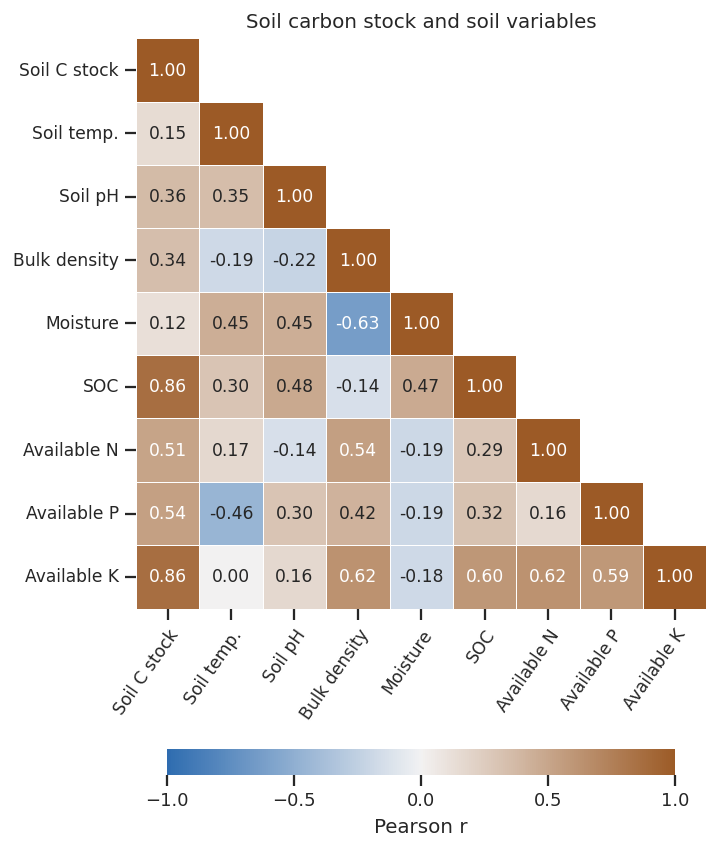

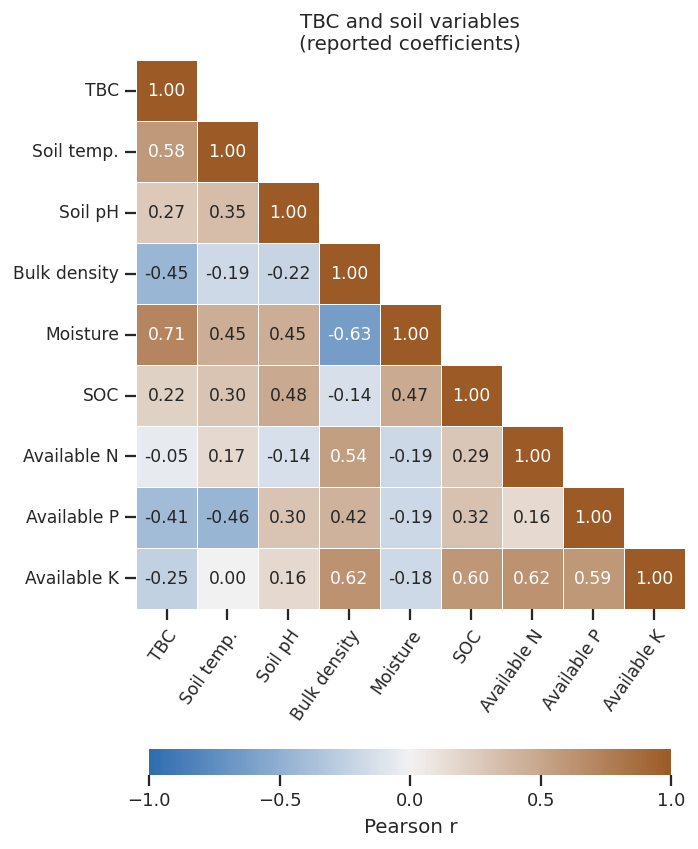

In [3]:
def plot_matrix(sheet):
    r = matrices[sheet]["r"].rename(index=short, columns=short)
    p = len(r)
    blocks = [(0,p,0,p,"full")] if p <= 9 else [
        (0,7,0,7,"1"), (7,p,0,7,"2"), (7,p,7,p,"3")]
    for r0,r1,c0,c1,part in blocks:
        values = r.iloc[r0:r1,c0:c1]
        mask = np.arange(c0,c1)[None,:] > np.arange(r0,r1)[:,None]
        fig, ax = plt.subplots(figsize=(WIDTH, 6.4), layout="constrained")
        sns.heatmap(values, mask=mask, vmin=-1, vmax=1, center=0, cmap=CMAP,
                    square=True, annot=True, fmt=".2f", annot_kws={"fontsize":9.5},
                    linewidths=0.5, linecolor="white",
                    cbar_kws={"label":"Pearson r", "orientation":"horizontal",
                              "shrink":0.65, "pad":0.04, "ticks":[-1,-0.5,0,0.5,1]}, ax=ax)
        title = titles[sheet].replace(" — reported coefficients", "\n(reported coefficients)")
        ax.set_title(title + (f"\nBlock {part} of 3" if p > 9 else ""), fontsize=11)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=55, ha="right", rotation_mode="anchor")
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
        ax.tick_params(axis="both", labelsize=9.5)
        save_show(fig, f"{sheet}_{part}",
                  titles[sheet] + f". Reported Pearson correlations from Heatmap.xlsx / {sheet}; N = 80 records per pair. "
                  + (f"Block {part} of 3; all three blocks are needed for the complete matrix. " if p > 9 else "")
                  + "Upper-triangle duplicates are omitted. No significance stars are shown; repeated-site dependence and multiple comparisons are not adjusted. "
                  + ("TBC response coefficients cannot be checked against authentic raw biomass data." if sheet in ["heatmap2","heatmap3"] else ""))

plot_matrix("heatmap1")
plot_matrix("heatmap2")

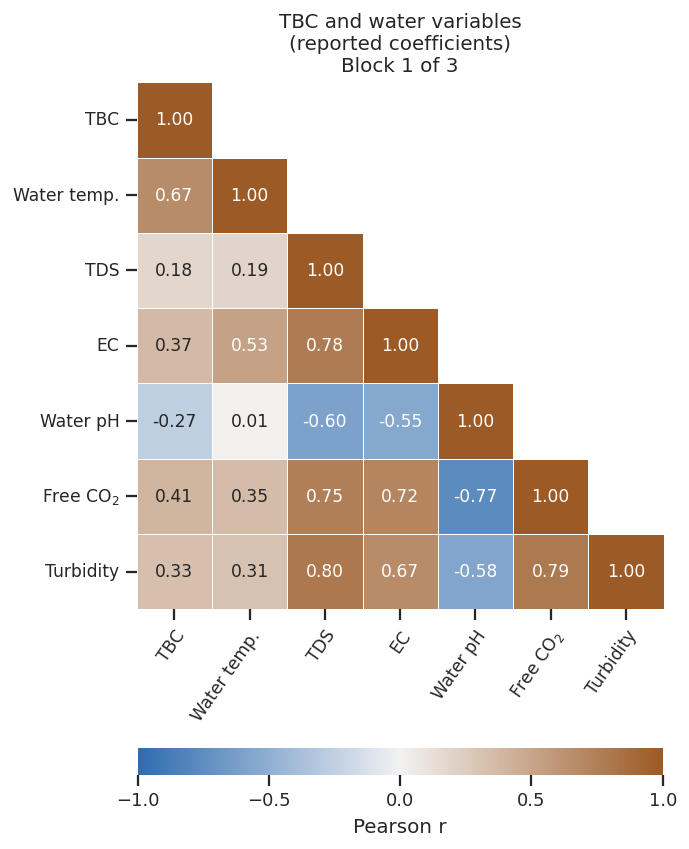

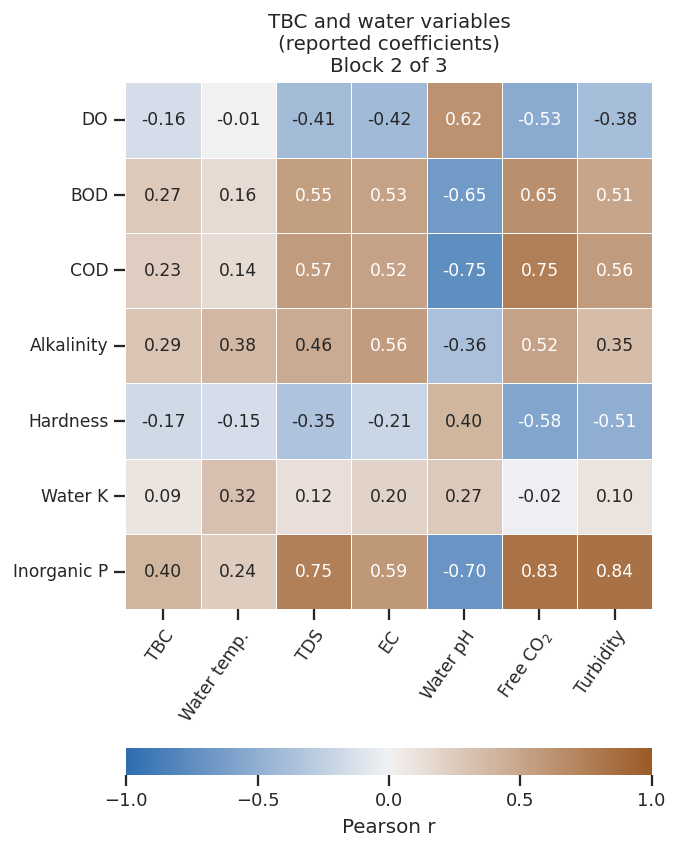

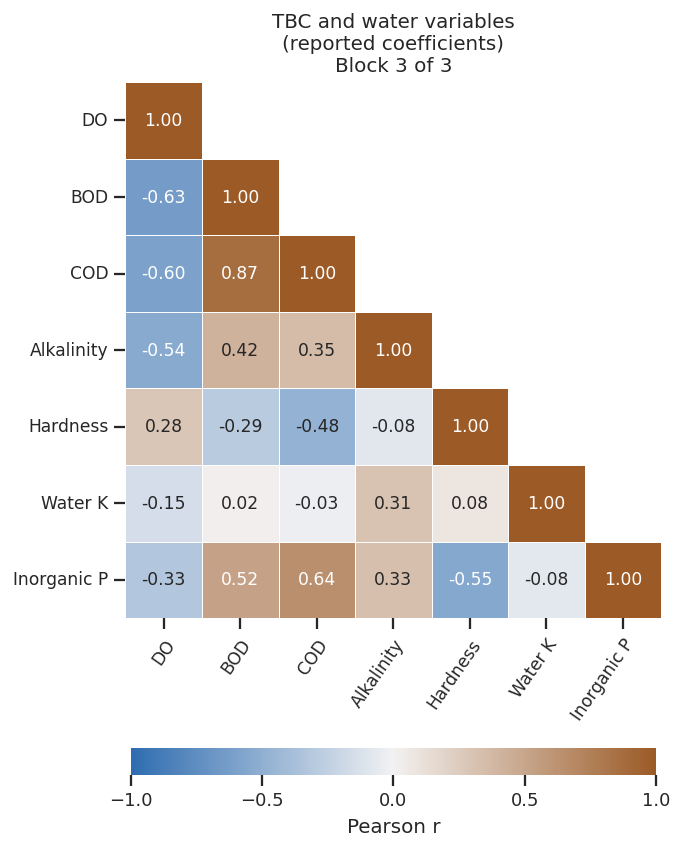

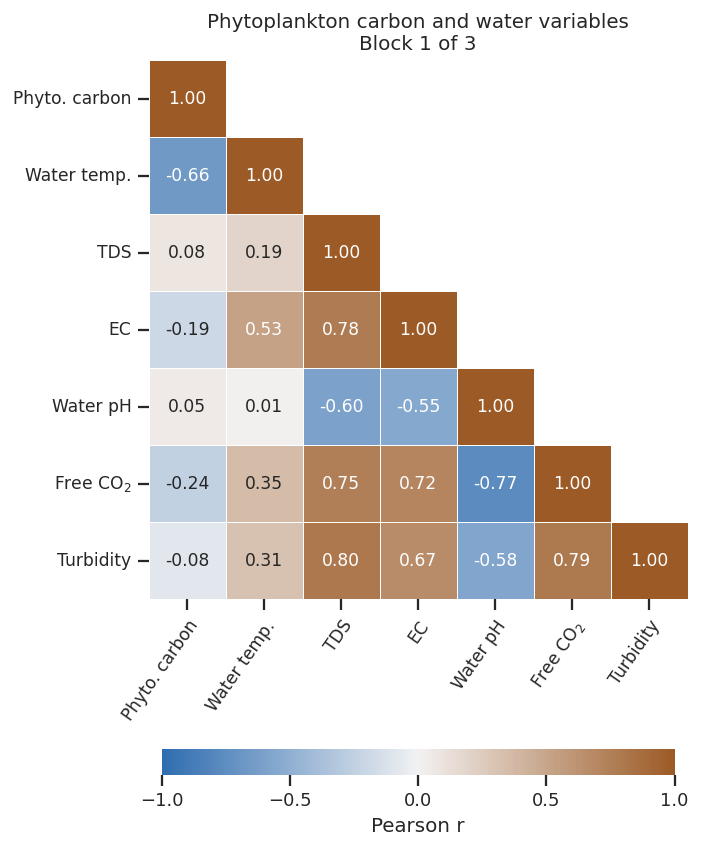

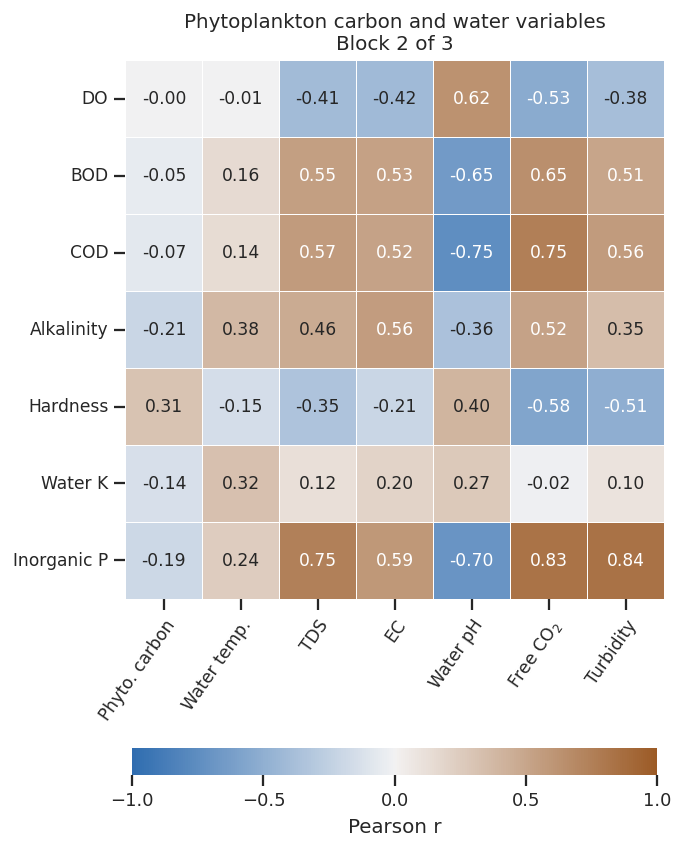

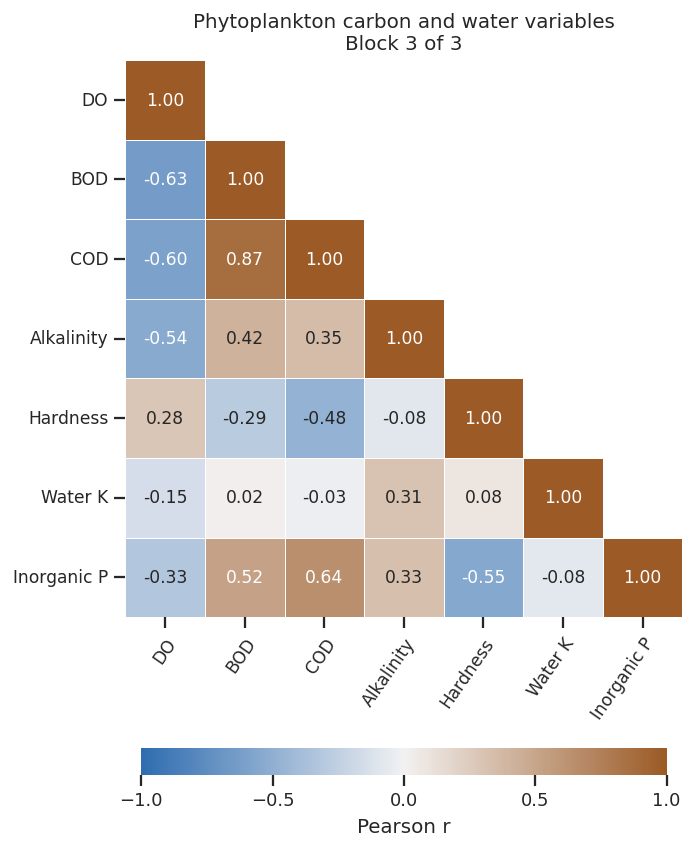

In [4]:
plot_matrix("heatmap3")
plot_matrix("heatmap4")

## 2. Carbon-response overview

These two figures retain every supplied environmental association with the carbon
responses. Soil and water variables are shown separately. The TBC columns remain
reported results because valid raw TBC observations are unavailable.

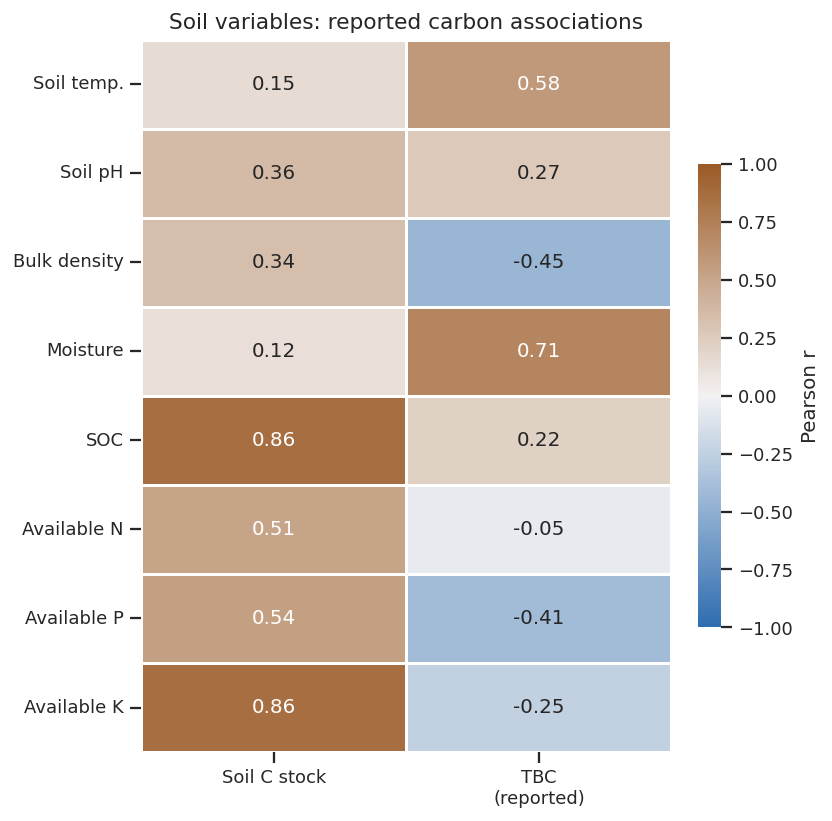

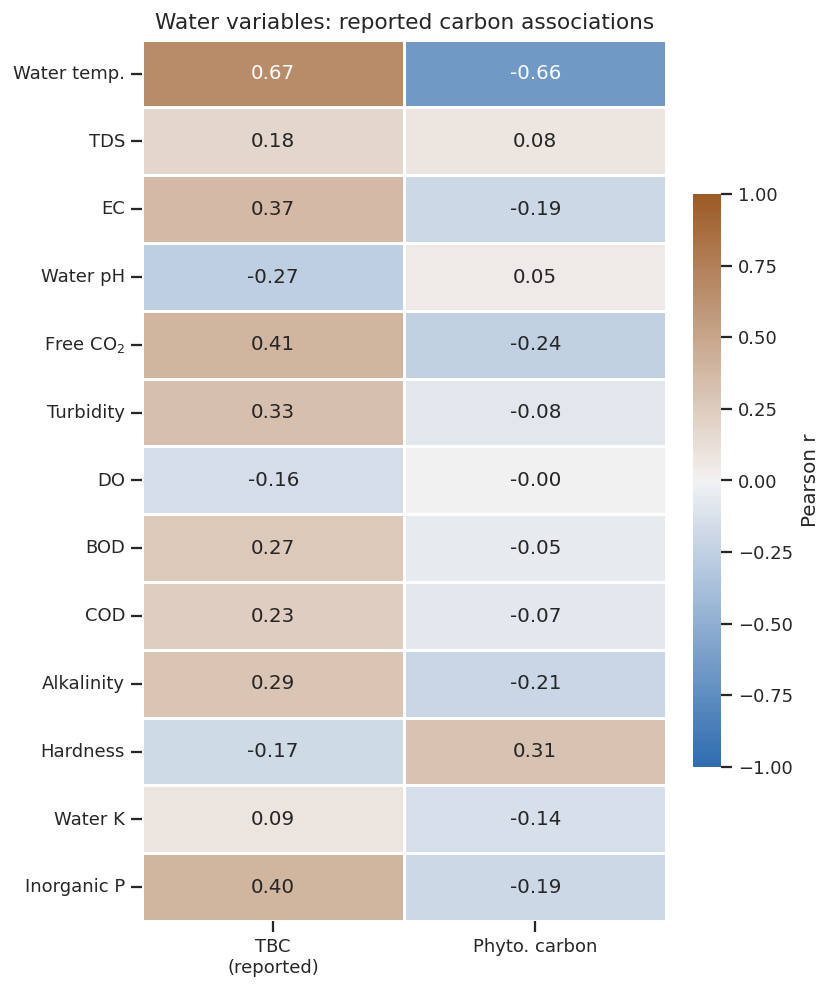

In [5]:
for sheets, labels, compartment in [
    (["heatmap1","heatmap2"], ["Soil C stock","TBC\n(reported)"], "Soil"),
    (["heatmap3","heatmap4"], ["TBC\n(reported)","Phyto. carbon"], "Water"),
]:
    overview = pd.concat([matrices[s]["r"].iloc[0,1:].rename(label)
                          for s,label in zip(sheets,labels)],axis=1).rename(index=short)
    fig, ax = plt.subplots(figsize=(WIDTH, 6.2 if compartment == "Soil" else 7.5), layout="constrained")
    sns.heatmap(overview, annot=True, fmt=".2f", cmap=CMAP, vmin=-1, vmax=1, center=0,
                linewidths=0.7, annot_kws={"fontsize":11},
                cbar_kws={"label":"Pearson r", "shrink":0.65}, ax=ax)
    ax.set(title=f"{compartment} variables: reported carbon associations", xlabel="", ylabel="")
    ax.tick_params(axis="both", rotation=0)
    save_show(fig, f"carbon_response_{compartment.lower()}",
              f"{compartment} environmental variables versus carbon responses: coefficients as reported in Heatmap.xlsx. Each entry uses 80 records. TBC coefficients are not verified against raw biomass data. Values are pooled associations, not season- or site-adjusted effects.")

## 3. Compare exported coefficients with the available observations

For soil stock and phytoplankton carbon, recompute the **entire** matrix using keyed
joins to the supplied environmental observations. For TBC sheets, check the environmental
submatrix only. Differences up to about $5\times10^{-4}$ can reflect three-decimal
rounding in exported cells. Larger discrepancies are retained for inspection; the heatmaps
above continue to show the original coefficients, not replacements.

For these files, the maximum absolute differences are **0.00854** for soil-variable
matrices and **0.00348** for water-variable matrices. These exceed rounding of the
exported coefficients alone; underlying measurement precision or dataset versions may
differ. The available files do not identify the cause.

In [6]:
scatter, _ = load_scatter()
environment = {name:decode_pca(frame) for name,frame in load_pca().items()}
soil = environment["Soil"].merge(scatter[KEYS+["Soil_Temp","Soil_stock"]], on=KEYS, validate="one_to_one")
water = environment["Water"].merge(scatter[KEYS+["Phyto_carbon"]], on=KEYS, validate="one_to_one")
soil_names = {"Soil Carbon Stock":"Soil_stock", "soil temperature":"Soil_Temp", "pH":"Soil_pH",
              "bulk density":"BD", "soil moisture":"Moisture", "SOC":"SOC",
              "available nitrogen":"N", "available phosphorus":"P", "available potassium":"K"}
water_names = {"Phytoplankton carbon":"Phyto_carbon", "water temperature":"Water_Temp",
               "TDS":"TDS", "EC":"EC", "water pH":"Water_pH", "co2":"CO2", "Turbidity":"Turbidity",
               "do":"DO", "bod":"BOD", "cod":"COD", "alkalinity":"Alkalinity", "hardness":"Hardness",
               "Potassium":"Water_K", "inorganic phosphorus":"Inorg_P"}
checks = []
for sheet, source, names in [("heatmap1",soil,soil_names),("heatmap2",soil,soil_names),
                              ("heatmap3",water,water_names),("heatmap4",water,water_names)]:
    supplied = matrices[sheet]["r"]
    usable = [label for label in supplied if label in names]
    recalculated = source[[names[label] for label in usable]].corr()
    recalculated.index = recalculated.columns = usable
    recalculated.to_csv(TABLE_DIR / f"{sheet}_r_recalculated_available_variables.csv")
    for i, a in enumerate(usable):
        for b in usable[:i]:
            checks.append({"Sheet":sheet, "Variable A":a, "Variable B":b,
                           "Reported r":supplied.loc[a,b], "Recomputed r":recalculated.loc[a,b],
                           "Absolute difference":abs(supplied.loc[a,b]-recalculated.loc[a,b])})
checks = pd.DataFrame(checks)
display(checks.groupby("Sheet")["Absolute difference"].agg(["count","max"]))
print("Largest discrepancies (complete audit saved to CSV):")
display(checks.loc[checks["Absolute difference"] > 0.00051].sort_values("Absolute difference",ascending=False).head(10))
checks.to_csv(TABLE_DIR / "correlation_source_audit.csv", index=False)
print("TBC response correlations remain unverified because authentic raw TBC is unavailable.")

,count,max
Sheet,,
heatmap1,36,0.008539
heatmap2,28,0.008539
heatmap3,78,0.003475
heatmap4,91,0.003475


Largest discrepancies (complete audit saved to CSV):


,Sheet,Variable A,Variable B,Reported r,Recomputed r,Absolute difference
24,heatmap1,available phosphorus,bulk density,0.417000,0.425539,0.008539
53,heatmap2,available phosphorus,bulk density,0.417000,0.425539,0.008539
44,heatmap2,SOC,bulk density,-0.137983,-0.130732,0.007251
13,heatmap1,SOC,bulk density,-0.137983,-0.130732,0.007251
38,heatmap2,bulk density,pH,-0.224000,-0.217778,0.006222
5,heatmap1,bulk density,pH,-0.224000,-0.217778,0.006222
9,heatmap1,soil moisture,bulk density,-0.626000,-0.620072,0.005928
41,heatmap2,soil moisture,bulk density,-0.626000,-0.620072,0.005928
3,heatmap1,bulk density,Soil Carbon Stock,0.339000,0.344511,0.005511
8,heatmap1,soil moisture,pH,0.448000,0.452130,0.004130


TBC response correlations remain unverified because authentic raw TBC is unavailable.


## Conclusions and use in the thesis

The supplied table reports strong positive associations of soil stock with **SOC
(r = 0.865)** and **available K (r = 0.863)**. SOC may enter the stock calculation;
the within-lake comparison in notebook 01 shows that the pooled K association does
not describe a consistent within-lake trend.

Reported TBC has a positive association with soil moisture (**r = 0.715**) and water
temperature (**r = 0.665**), while phytoplankton carbon has a negative association
with water temperature (**r = −0.661**). This contrast motivates examining seasonal
patterns; it does not establish opposing causal temperature responses. The TBC
coefficients cannot currently be reproduced from valid site-level biomass data.

Environmental variables are also correlated, so a set of large pairwise coefficients
must not be interpreted as several independent effects. No significance claims are
made here. Reported and recomputed coefficients differ by up to **0.00854** in the
soil matrices and **0.00348** in the water matrices. The audit retains both versions;
the available files do not establish the cause. Resolve these provenance differences
before using exact coefficient values as final thesis results.